In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

import scanpy as sc
import numpy as np
import anndata as ad

from tqdm.notebook import tqdm

In [2]:
adata = sc.read_h5ad("/home/icb/alessandro.palma/environment/scExpDesign-Reproducibility/project_folder/datasets/combosciplex/combosciplex.h5ad")
adata = adata[:, adata.var.highly_variable]

In [3]:
adata

View of AnnData object with n_obs × n_vars = 63378 × 5000
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mean = nn.Linear(hidden_dim, latent_dim)
        self.log_var = nn.Linear(hidden_dim, latent_dim)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        z_mean = self.mean(x)
        z_log_var = self.log_var(x)
        return z_mean, z_log_var

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.reconstruct = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, z):
        z = torch.relu(self.fc1(z))
        z = torch.relu(self.fc2(z))
        return self.reconstruct(z)

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)
    
    def reparameterize(self, mean, log_var):
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)
        return mean + epsilon * std
    
    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, z_mean, z_log_var

    def get_latent(self, x):
        z_mean, z_log_var = self.encoder(x)
        return z_mean

    def reconstruct(self, x):
        z_mean, z_log_var = self.encoder(x)
        reconstructed_x = self.decoder(z_mean)
        return reconstructed_x

In [5]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data).float()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = CustomDataset(adata.X.toarray())
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=10
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        recon_x, mean, log_var = model(batch)
        
        recon_loss = loss_fn(recon_x, batch)
        kl_divergence = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        loss = recon_loss + 1e-6 * kl_divergence

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {kl_divergence.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1171
Epoch [1/20], Loss: 1643.8560
Epoch [2/20], Loss: 0.1155
Epoch [2/20], Loss: 1398.4548
Epoch [3/20], Loss: 0.1147
Epoch [3/20], Loss: 1518.8677
Epoch [4/20], Loss: 0.1137
Epoch [4/20], Loss: 1664.2438
Epoch [5/20], Loss: 0.1137
Epoch [5/20], Loss: 2046.4246
Epoch [6/20], Loss: 0.1133
Epoch [6/20], Loss: 2293.1172
Epoch [7/20], Loss: 0.1124
Epoch [7/20], Loss: 2267.5215
Epoch [8/20], Loss: 0.1141
Epoch [8/20], Loss: 2259.6958
Epoch [9/20], Loss: 0.1133
Epoch [9/20], Loss: 2321.2729
Epoch [10/20], Loss: 0.1120
Epoch [10/20], Loss: 2247.2729
Epoch [11/20], Loss: 0.1124
Epoch [11/20], Loss: 2291.3940
Epoch [12/20], Loss: 0.1123
Epoch [12/20], Loss: 2372.3467
Epoch [13/20], Loss: 0.1120
Epoch [13/20], Loss: 2321.8628
Epoch [14/20], Loss: 0.1119
Epoch [14/20], Loss: 2253.6577
Epoch [15/20], Loss: 0.1117
Epoch [15/20], Loss: 2432.2998
Epoch [16/20], Loss: 0.1126
Epoch [16/20], Loss: 2302.3091
Epoch [17/20], Loss: 0.1117
Epoch [17/20], Loss: 2418.5352
Epoch [18/20], 

In [7]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model.reconstruct(torch.tensor(orig).float().to(device)).cpu().numpy()

In [8]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


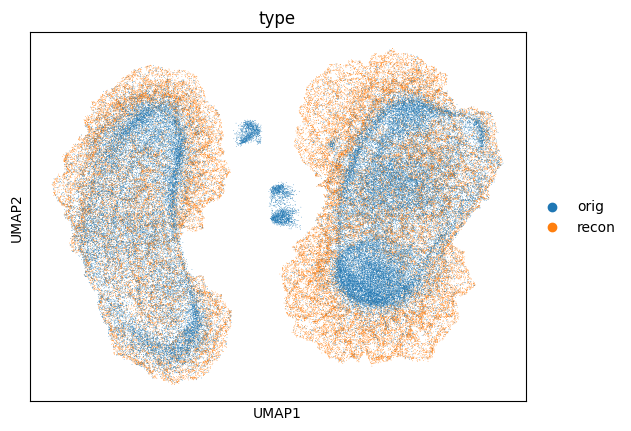

In [9]:
sc.pl.umap(combined, color="type")

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=10
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        recon_x, mean, log_var = model(batch)
        
        recon_loss = loss_fn(recon_x, batch)
        kl_divergence = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        loss = recon_loss + 1e-7 * kl_divergence

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {kl_divergence.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1147
Epoch [1/20], Loss: 10045.3857
Epoch [2/20], Loss: 0.1124
Epoch [2/20], Loss: 7660.5879
Epoch [3/20], Loss: 0.1102
Epoch [3/20], Loss: 7116.9995
Epoch [4/20], Loss: 0.1091
Epoch [4/20], Loss: 6982.0303
Epoch [5/20], Loss: 0.1087
Epoch [5/20], Loss: 7085.3848
Epoch [6/20], Loss: 0.1098
Epoch [6/20], Loss: 6959.9951
Epoch [7/20], Loss: 0.1089
Epoch [7/20], Loss: 7072.3472
Epoch [8/20], Loss: 0.1076
Epoch [8/20], Loss: 7706.6704
Epoch [9/20], Loss: 0.1081
Epoch [9/20], Loss: 8253.6055
Epoch [10/20], Loss: 0.1078
Epoch [10/20], Loss: 8437.2285
Epoch [11/20], Loss: 0.1078
Epoch [11/20], Loss: 9126.3535
Epoch [12/20], Loss: 0.1065
Epoch [12/20], Loss: 9235.8047
Epoch [13/20], Loss: 0.1065
Epoch [13/20], Loss: 9567.7969
Epoch [14/20], Loss: 0.1055
Epoch [14/20], Loss: 10033.4297
Epoch [15/20], Loss: 0.1070
Epoch [15/20], Loss: 10442.8867
Epoch [16/20], Loss: 0.1054
Epoch [16/20], Loss: 10984.2344
Epoch [17/20], Loss: 0.1065
Epoch [17/20], Loss: 11602.1348
Epoch [18/

Created
PCA
Neighbors
Finished


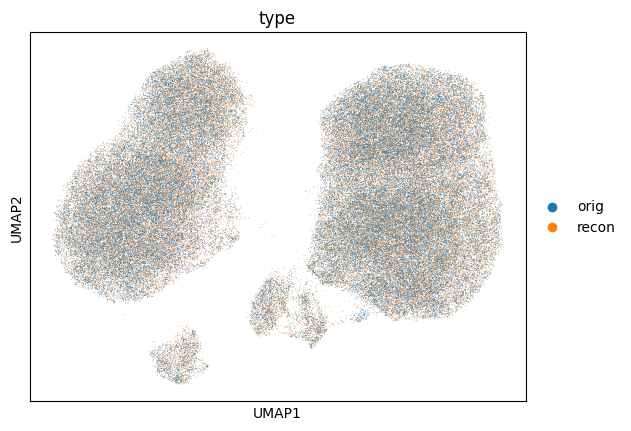

In [11]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model.reconstruct(torch.tensor(orig).float().to(device)).cpu().numpy()

obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")
sc.pl.umap(combined, color="type")

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=10
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        recon_x, mean, log_var = model(batch)
        
        recon_loss = loss_fn(recon_x, batch)
        kl_divergence = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        loss = recon_loss + 1e-100 * kl_divergence

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {kl_divergence.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1149
Epoch [1/20], Loss: 34820.4609
Epoch [2/20], Loss: 0.1107
Epoch [2/20], Loss: 45710.9844
Epoch [3/20], Loss: 0.1097
Epoch [3/20], Loss: 51947.5000
Epoch [4/20], Loss: 0.1092
Epoch [4/20], Loss: 52787.4531
Epoch [5/20], Loss: 0.1079
Epoch [5/20], Loss: 55224.2070
Epoch [6/20], Loss: 0.1072
Epoch [6/20], Loss: 56368.3984
Epoch [7/20], Loss: 0.1059
Epoch [7/20], Loss: 59883.1562
Epoch [8/20], Loss: 0.1050
Epoch [8/20], Loss: 57652.8438
Epoch [9/20], Loss: 0.1042
Epoch [9/20], Loss: 59232.8906
Epoch [10/20], Loss: 0.1043
Epoch [10/20], Loss: 60366.0039
Epoch [11/20], Loss: 0.1037
Epoch [11/20], Loss: 60537.9336
Epoch [12/20], Loss: 0.1024
Epoch [12/20], Loss: 61177.1445
Epoch [13/20], Loss: 0.1032
Epoch [13/20], Loss: 62517.7188
Epoch [14/20], Loss: 0.1034
Epoch [14/20], Loss: 61302.9414
Epoch [15/20], Loss: 0.1027
Epoch [15/20], Loss: 61925.0039
Epoch [16/20], Loss: 0.1028
Epoch [16/20], Loss: 62611.1836
Epoch [17/20], Loss: 0.1030
Epoch [17/20], Loss: 61951.179

Created
PCA
Neighbors
Finished


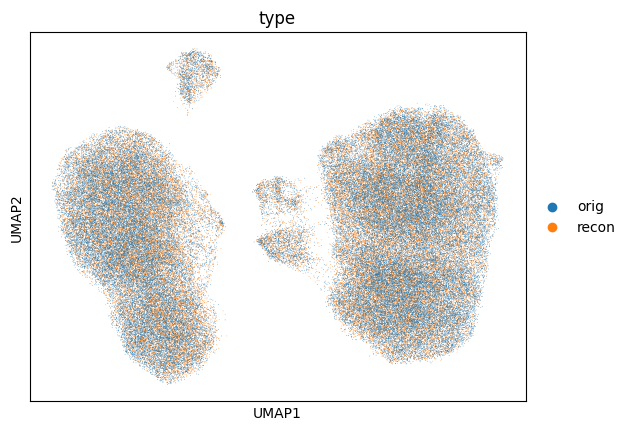

In [13]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model.reconstruct(torch.tensor(orig).float().to(device)).cpu().numpy()

obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")
sc.pl.umap(combined, color="type")